In [ ]:
!pip install xgboost
!pip install XGBClassifier
!!pip install XGBRegressor

ERROR: Could not find a version that satisfies the requirement XGBClassifier (from versions: none)
ERROR: No matching distribution found for XGBClassifier


['\x1bERROR: Could not find a version that satisfies the requirement XGBRegressor (from versions: none)\x1b\x1b',
 '\x1b\x1bERROR: No matching distribution found for XGBRegressor\x1b\x1b',
 '\x1b']

In [ ]:
!pip install pandas numpy seaborn matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

---
# Data Wrangling :
 - ### Loading Data
- ### Below I will load the data and show the first rows of the data and the information about each columns of the data.
---

In [ ]:
from google.colab import files
uploaded = files.upload()
df= pd.read_csv(r"WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df= pd.read_csv(r"WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.shape

(7043, 21)

---
## Data description :

- #### customerID	: Unique ID assigned to each customer
- #### gender	: Customer gender (Male / Female)
- #### SeniorCitizen	: Whether the customer is a senior citizen (1 = Yes, 0 = No)
- #### Partner	: Whether the customer has a partner (Yes / No)
- #### Dependents	: Whether the customer has dependents such as children or parents (Yes / No)
- #### tenure	: Number of months the customer has stayed with the company
- #### PhoneService	: Whether the customer has phone service (Yes / No)
- #### MultipleLines	: Whether the customer has multiple phone lines
- #### InternetService	: Type of internet service (DSL, Fiber optic, No)
- #### OnlineSecurity	: Whether the customer has online security service
- #### OnlineBackup	: Whether the customer has online backup service
- #### DeviceProtection	: Whether the customer has device protection service
- #### TechSupport	: Whether the customer has tech support service
- #### StreamingTV	: Whether the customer uses streaming TV service
- #### StreamingMovies	: Whether the customer uses streaming movie service
- #### Contract	: Contract type (Month-to-month, One year, Two year)
- #### PaperlessBilling	: Whether the customer uses paperless billing
- #### PaymentMethod	: Payment method used by the customer
- #### MonthlyCharges	: Amount charged to the customer every month
- #### TotalCharges	: Total amount charged to the customer
- #### Churn	: Target variable indicating whether the customer left the service (Yes / No)
- --

---
## Checking for null values :
---

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


---
### No Null records found so let's move further :
---

---
## Fixing Column Names (if needed)
- ### First let's see the column names:
---

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

---
# Correcting Column names:
### As we can clearly see some columns are in Camel Style and some are in small first and capital at last
### So I'll replace all the columns to small case so no further confusion occurs
- #### customerID : customer_id
- #### SenoirCitizen : senior_citizen
- #### Partner : partner
- #### Dependents : dependents
- #### PhoneSevice : phone_service
- #### MultipleLines : multiple_lines
- #### InternetService : internet_service
- #### OnlineSecurity : online_security
- #### OnlineBackup : online_backup
- #### DeviceProtection : device_protection
- #### TechSupport : tech_support
- #### StreamingTV : streaming_tv
- #### StreamingMovies : streaming_movies
- #### Contract : contract
- #### PaperlessBilling : paperless_billing
- #### PaymentMethod : payment_method
- #### MonthlyCharges : monthly_charges
- #### TotalCharges : total_charges
- #### Churn : churn
---

In [ ]:
df.rename(columns=
          {
              'customerID' : 'customer_id', 'SeniorCitizen' : 'senior_citizen','Partner' : 'partner','Dependents' : 'dependents',
              'PhoneService' : 'phone_service','MultipleLines' : 'multiple_lines','InternetService' : 'internet_service',
              'OnlineSecurity' : 'online_security','OnlineBackup' : 'online_backup','DeviceProtection' : 'device_protection',
              'TechSupport' : 'tech_support','StreamingTV' : 'streaming_tv','StreamingMovies' : 'streaming_movies','Contract' : 'contract',
              'PaperlessBilling' : 'paperless_billing','PaymentMethod' : 'payment_method','MonthlyCharges' : 'monthly_charges',
              'TotalCharges' : 'total_charges','Churn' : 'churn'
          },inplace=True
         )

In [ ]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

---
## Let's check the data types
---

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [ ]:
df.head(5)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
### As we can see that the total charges is in object form where it should have been float so let's change it into float
---

---
### The above error clearly demonstrates that there are white spaces in the column 'total_charges'.
### So first we have to deal with those white spaces first.
### Lets see if something's fishy
---

In [ ]:
df[df['total_charges'] == ' '  ]

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


---
### As we can clearly see that the tenure of the customers with total_charges = ' ' is 0.
### Which basically means that they just started their services which is pretty obvious
- ### I'll first replace the white space with 0
- ---

In [ ]:
df['total_charges'] = df['total_charges'].replace(' ','0')

---
### Let's check if it's replaced
---

In [ ]:
df[df['total_charges'] == ' '  ]

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn


---
### Now as we have replaced the whitespaces with 0 let's change the datatype to float
---

In [ ]:
df['total_charges']= df['total_charges'].astype(float)

---
### Let's check
---

In [ ]:
df['total_charges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: total_charges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


---
### Now I'll change the values in senior_citizen and also I'll change it's datatype from int64 to object

| Values       | Replacing with   |
|--------------|-------------|
| **0**        | No          |
| **1**        | Yes         |

### This is easy to understand for everyone than 0,1
---

In [ ]:
df['senior_citizen'].replace( {0: 'No',1: 'Yes'},inplace=True)

In [ ]:
df['senior_citizen'].value_counts()

,count
senior_citizen,
No,5901
Yes,1142


---
### Datatype has been changed too
---

In [ ]:
df['senior_citizen'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: senior_citizen
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


---
### Lets see if are there any duplicate rows :
---

In [ ]:
df.duplicated().sum()

np.int64(0)

---
### Let's see if there are any duplicate customer_id
---

In [ ]:
df['customer_id'].duplicated().sum()

np.int64(0)

---
### No duplicate customer_ids
### Lets move ahead
---

# **EDA**

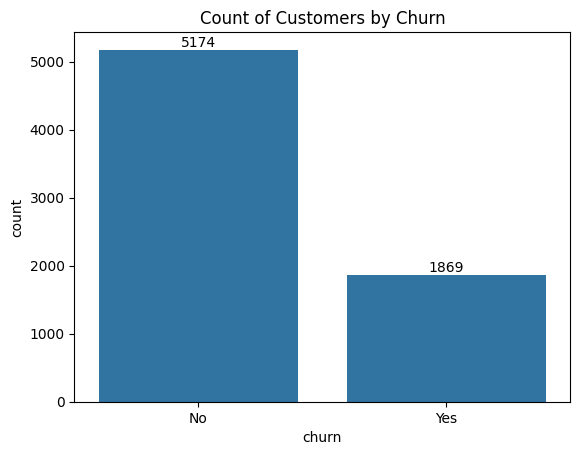

In [ ]:
# @title
ax = sns.countplot(x = 'churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

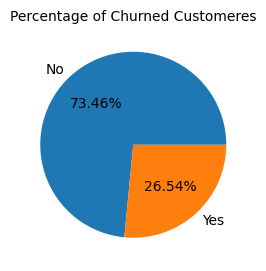

In [ ]:
# @title
plt.figure(figsize = (3,4))
gb = df.groupby("churn").agg({'churn':"count"})
plt.pie(gb['churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()

## from the given pie chart we can conclude that 26.54% of our customers have churned out.
## not let's explore the reason behind it

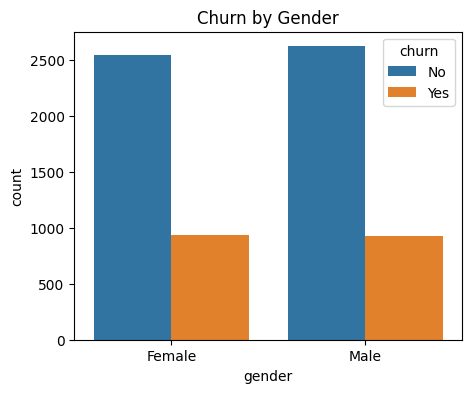

In [ ]:
# @title
plt.figure(figsize = (5,4))
sns.countplot(x = "gender", data = df, hue = "churn")
plt.title("Churn by Gender")
plt.show()

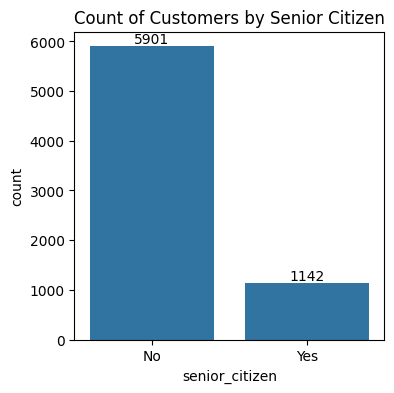

In [ ]:
# @title
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "senior_citizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen")
plt.show()

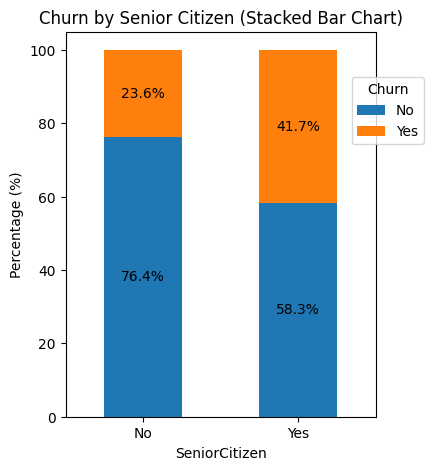

In [ ]:
# @title
total_counts = df.groupby('senior_citizen')['churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 5))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')
#---------------------------------------------------------------------------------------------------------------
plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))
plt.show()
#------------------------------------------------------------------------------------------------------------

##comparative a greater pecentage of people in senior citizen category have churned

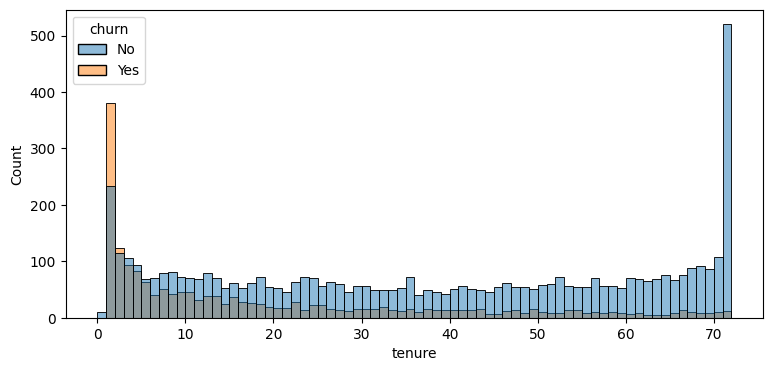

In [ ]:
# @title
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "churn")
plt.show()

##people who have used our services for a long time have stayed and people who have used our sevices
#1 or 2 months  have churned

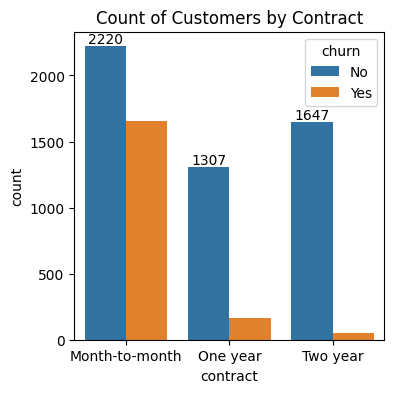

In [ ]:
# @title
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "contract", data = df, hue = "churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

##people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract.

In [ ]:
# @title
df.columns.values

array(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection',
       'tech_support', 'streaming_tv', 'streaming_movies', 'contract',
       'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn'], dtype=object)

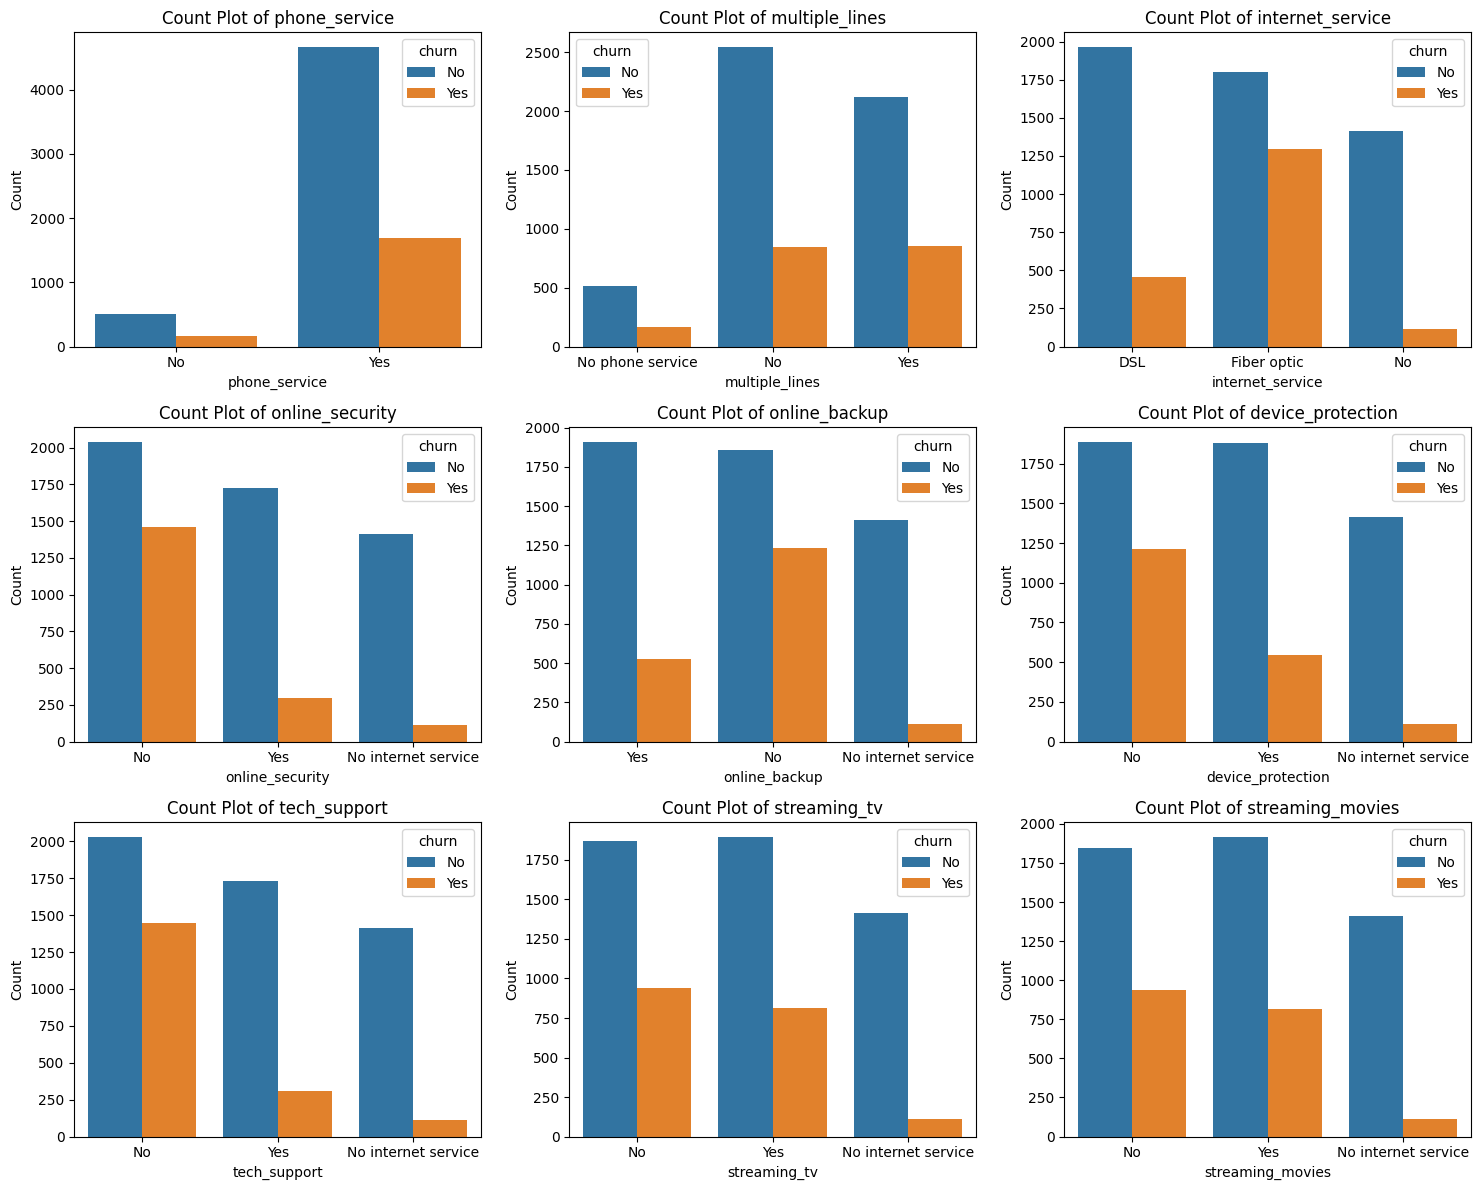

In [ ]:
# @title
columns = ['phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection',
       'tech_support', 'streaming_tv', 'streaming_movies']

# Number of columns for the subplot grid
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

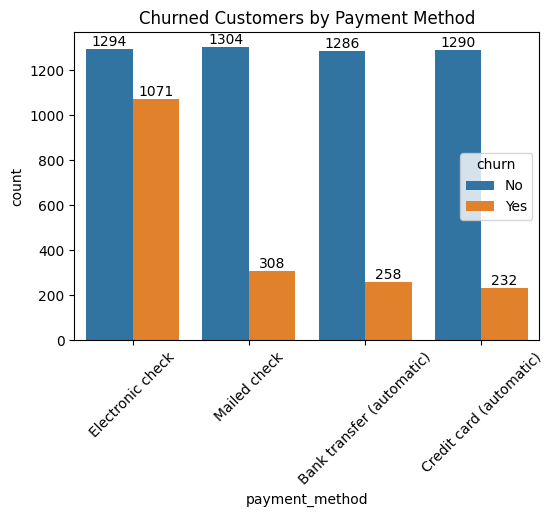

In [ ]:
# @title
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "payment_method", data = df, hue = "churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

##customer is likely to churn when he is using electronic check as a payment method.

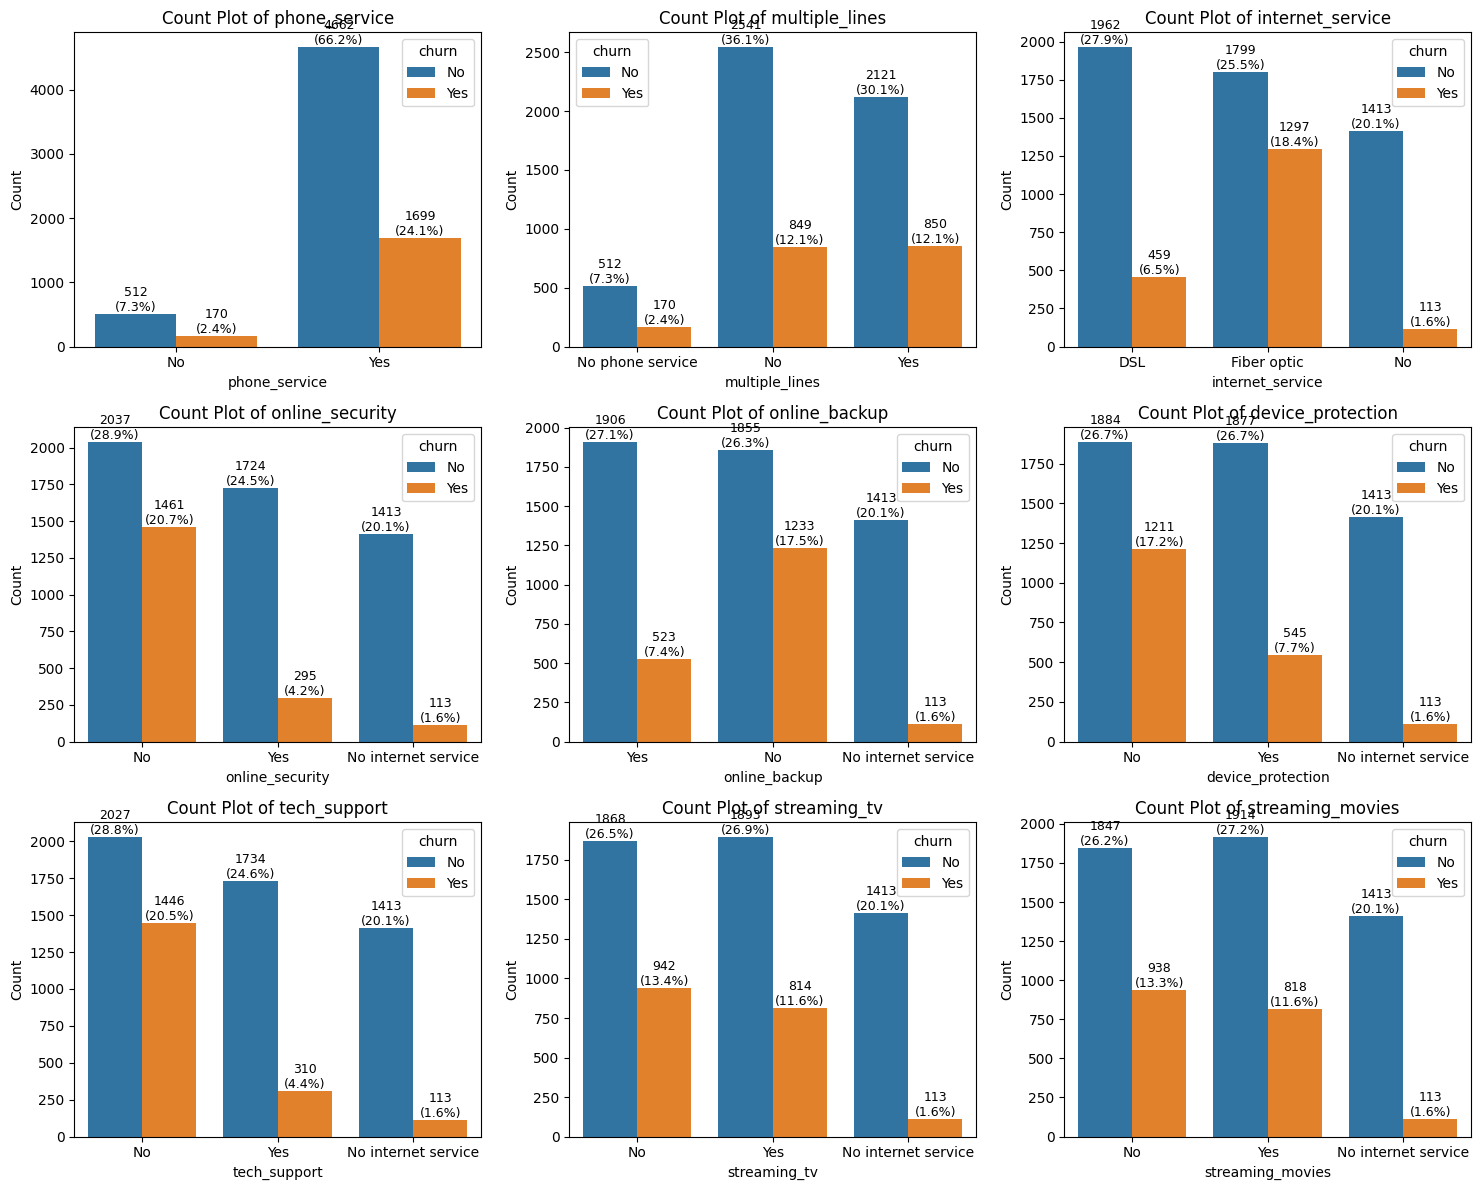

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection',
       'tech_support', 'streaming_tv', 'streaming_movies']

n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = sns.countplot(x=col, data=df, ax=axes[i], hue=df["churn"])

    total = len(df)

    # Add count + percentage labels
    for p in ax.patches:
        count = int(p.get_height())
        percentage = (count / total) * 100

        if count > 0:
            ax.annotate(f'{count}\n({percentage:.1f}%)',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9)

    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

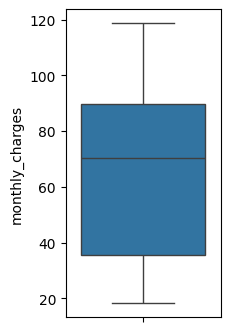

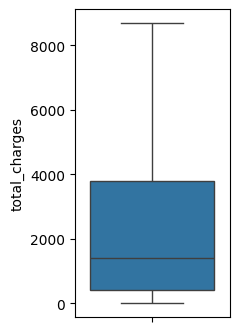

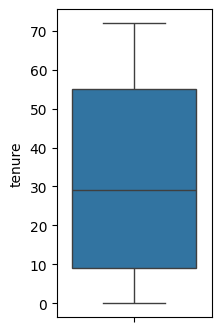

In [ ]:
col  = ['monthly_charges', 'total_charges', 'tenure']

for i in col:
  plt.figure(figsize=(2, 4))
  sns.boxplot(df[i])
  plt.show()


In [ ]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

# Ready data for ml

In [ ]:
df = df.drop('customer_id' , axis= 1)

In [ ]:
df['churn'] = df['churn'].replace('Yes','1')

In [ ]:
df['churn'] = df['churn'].replace('No','0')

In [ ]:
df['churn'] = df['churn'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   senior_citizen     7043 non-null   object 
 2   partner            7043 non-null   object 
 3   dependents         7043 non-null   object 
 4   tenure             7043 non-null   int64  
 5   phone_service      7043 non-null   object 
 6   multiple_lines     7043 non-null   object 
 7   internet_service   7043 non-null   object 
 8   online_security    7043 non-null   object 
 9   online_backup      7043 non-null   object 
 10  device_protection  7043 non-null   object 
 11  tech_support       7043 non-null   object 
 12  streaming_tv       7043 non-null   object 
 13  streaming_movies   7043 non-null   object 
 14  contract           7043 non-null   object 
 15  paperless_billing  7043 non-null   object 
 16  payment_method     7043 

In [ ]:
for col in df.columns:
  print(f'======={col}=======')
  print(df[col].unique())
  print('*' * 50)


=======gender=======
['Female' 'Male']
**************************************************
=======senior_citizen=======
['No' 'Yes']
**************************************************
=======partner=======
['Yes' 'No']
**************************************************
=======dependents=======
['No' 'Yes']
**************************************************
=======tenure=======
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
**************************************************
=======phone_service=======
['No' 'Yes']
**************************************************
=======multiple_lines=======
['No phone service' 'No' 'Yes']
**************************************************
=======internet_service=======
['DSL' 'Fiber optic' 'No']
**************************************************
=======online_security=======
['N

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

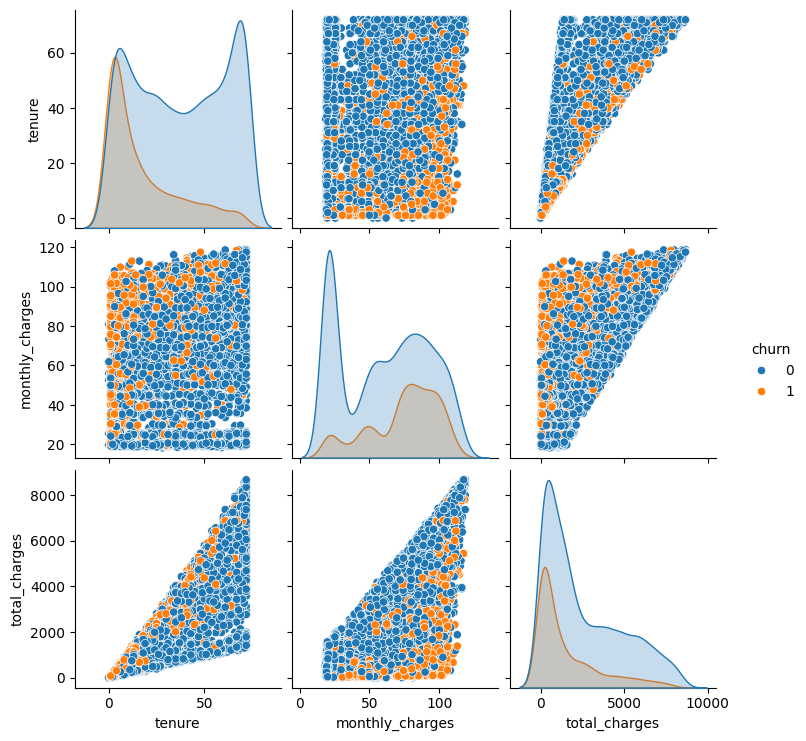

In [ ]:
sns.pairplot(data=df, hue='churn')
plt.show()

# Creating ML model

## LogisticRegression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder , OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [ ]:
num_feture = ['monthly_charges', 'total_charges','tenure']
nominal_feture = [ 'gender', 'senior_citizen', 'partner', 'dependents',
        'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']

In [ ]:
preprocesser = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_feture),
        ('nom',OneHotEncoder(drop='first'), nominal_feture)
    ])

In [ ]:
X = df.drop('churn',axis=1)
y = df['churn']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
model = Pipeline(steps=[
    ('preprocessing',preprocesser),
    ('classifier',LogisticRegression())
])

In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('classifier', LogisticRegression())])

In [ ]:
y_pred = model.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('*' * 50)
print(classification_report(y_test,y_pred))

Accuracy : 0.8062455642299503
**************************************************
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

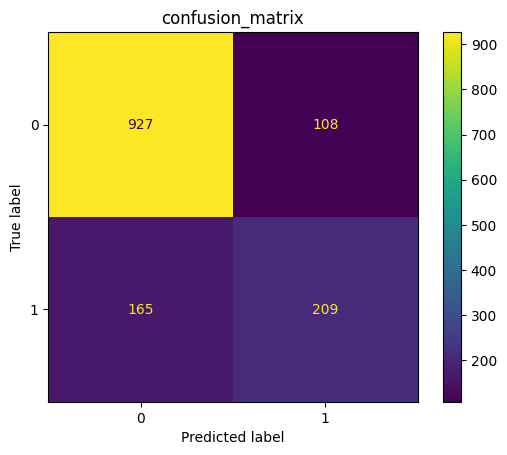

In [ ]:
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
plt.title('confusion_matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve , roc_auc_score

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]
tpr ,fpr , _ = roc_curve(y_test ,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
auc_score

np.float64(0.8421710713270816)

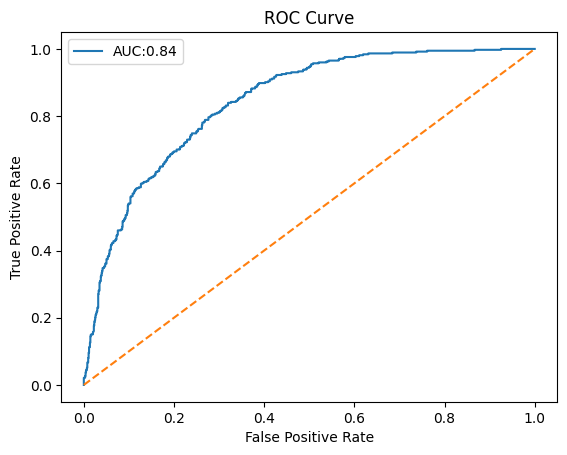

In [ ]:
plt.plot(tpr,fpr,label = f'AUC:{auc_score:.2f}')
plt.plot([0,1],[0,1],linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
feture_name = model.named_steps['preprocessing'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'Feture': feture_name ,
                        'Coefficient': coefficients}).sort_values(by='Coefficient',ascending=False)
coef_df

,Feture,Coefficient
10,nom__internet_service_Fiber optic,1.180666
1,num__total_charges,0.527772
28,nom__payment_method_Electronic check,0.392775
21,nom__streaming_tv_Yes,0.374831
26,nom__paperless_billing_Yes,0.374218
23,nom__streaming_movies_Yes,0.373193
9,nom__multiple_lines_Yes,0.361646
4,nom__senior_citizen_Yes,0.147911
29,nom__payment_method_Mailed check,0.081866
17,nom__device_protection_Yes,0.033106


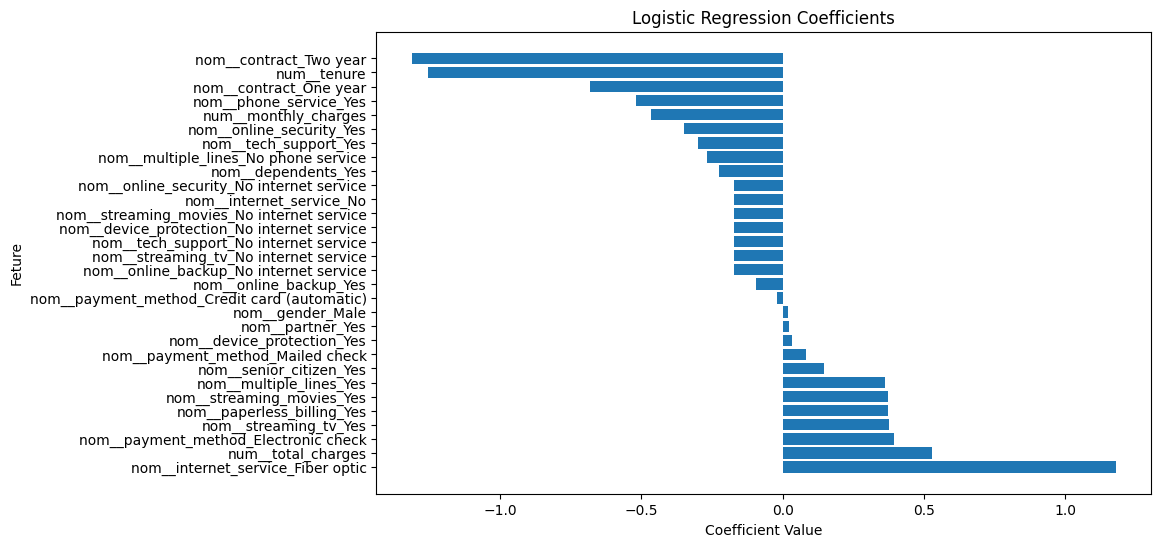

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feture'],coef_df['Coefficient'])
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feture')
plt.show()

In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.8058217962371317
Test Accuracy: 0.8062455642299503


## Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder, OneHotEncoder , OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [ ]:
cat_col = ['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']
num_col = ['monthly_charges', 'total_charges','tenure']

In [ ]:
preprocesser = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_col),
        ('cat',OneHotEncoder(drop='first'),cat_col)
    ])

In [ ]:
X  = df.drop('churn',axis=1)
y = df['churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
model = Pipeline(steps = [
    ('preprocessing',preprocesser),
    ('classifier',DecisionTreeClassifier())
])

In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('classifier', DecisionTreeClassifier())])

In [ ]:
y_pred = model.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')

Accuracy : 0.7260468417317246


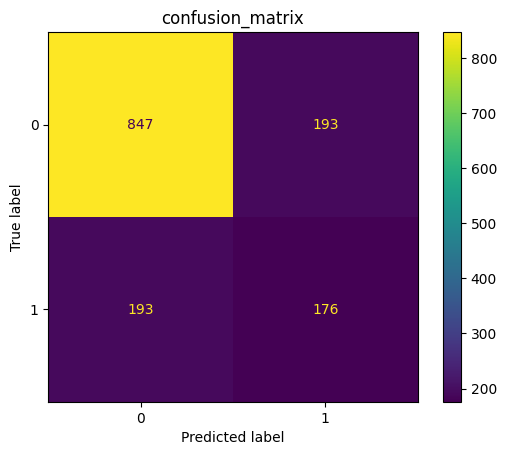

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd
cmd.from_estimator(model,X_test,y_test)
plt.title('confusion_matrix')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

train_acc = []
test_acc= []

for i in range(1,100):
    model = Pipeline(
        steps=[
            ('preprocess', preprocesser),
            ('classifier',DecisionTreeClassifier(
                max_depth=i,
                random_state=3))])
    model.fit(X_train,y_train)
    train_acc.append(model.score(X_train,y_train))
    test_acc.append(model.score(X_test,y_test))

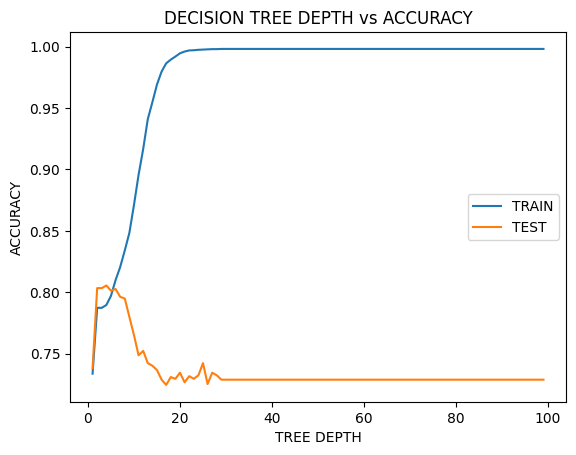

In [ ]:
plt.plot(range(1,100),train_acc, label='TRAIN')
plt.plot(range(1,100),test_acc,label="TEST")
plt.legend()
plt.xlabel("TREE DEPTH")
plt.ylabel("ACCURACY")
plt.title("DECISION TREE DEPTH vs ACCURACY")
plt.show()

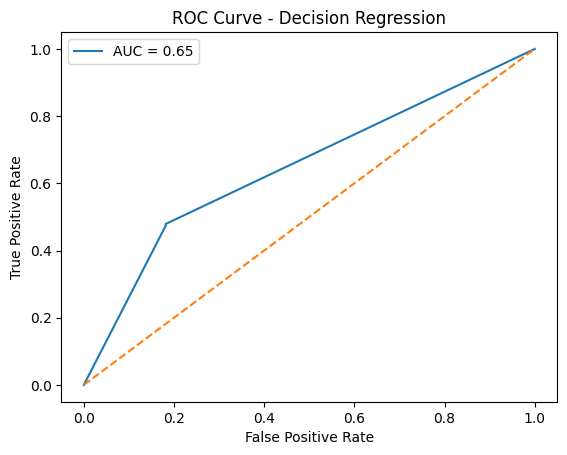

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder

y_prob = model.predict_proba(X_test) [:,1]

le = LabelEncoder()
y_test_encoder = le.fit_transform(y_test)

fpr, tpr, _= roc_curve(y_test_encoder,y_prob)
auc_score = roc_auc_score(y_test_encoder,y_prob)
plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {auc_score :.2f}")
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Regression")
plt. legend()
plt.show()

In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.9980475683351083
Test Accuracy: 0.7260468417317246


# RF

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [ ]:
cat =  ['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']
num = [ 'monthly_charges', 'total_charges', 'tenure']

In [ ]:
#model = Pipeline(steps=[
 #   ('preprocessing',preprocesser),
  #  ('classifier',LogisticRegression())
#])

In [ ]:
#preprocesser = ColumnTransformer(
 #   transformers=[
  #      ('num',StandardScaler(),num_feture),
   #     ('nom',OneHotEncoder(drop='first'), nominal_feture)
    #])

In [ ]:
preprocesser = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num),
        ('cat', OneHotEncoder(drop='first'),cat)
    ]
)

In [ ]:
model = Pipeline(steps=[
    ('preproessing' , preprocesser),
    ('classifier' , RandomForestClassifier(n_estimators=200,max_depth=8,random_state=42))
])

In [ ]:
X = df.drop('churn' , axis = 1)
y = df['churn']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('preproessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, n_estimators=200,
                                        random_state=42))])

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('*' * 50 )
print(classification_report(y_test,y_pred))

Accuracy : 0.8062455642299503
**************************************************
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



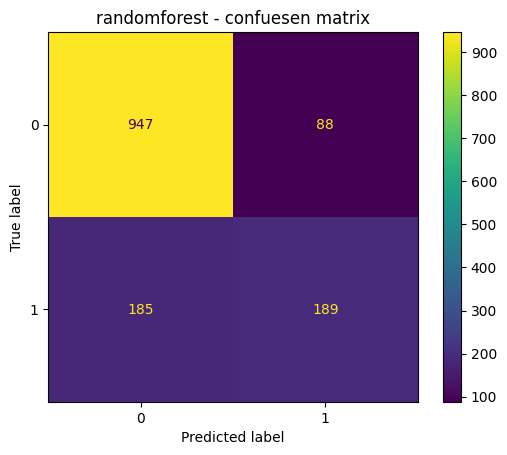

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd
cmd.from_estimator(model,X_test,y_test)
plt.title('randomforest - confuesen matrix')
plt.show()


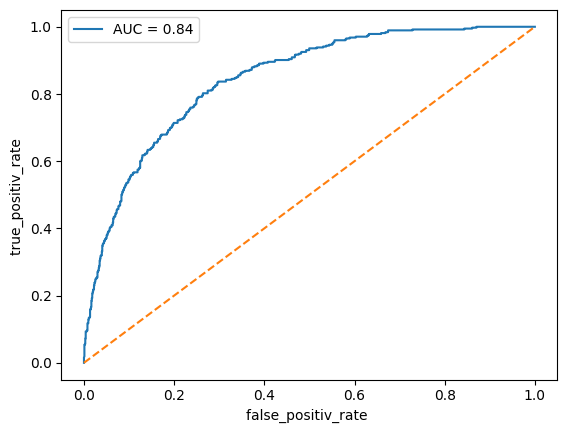

In [ ]:
fpr , tpr , _ = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test , y_prob)

plt.plot(fpr , tpr , label = f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('false_positiv_rate ')
plt.ylabel('true_positiv_rate ')
plt.legend()
plt.show()

In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.8320908768193114
Test Accuracy: 0.8062455642299503


# **Gradient_Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report,confusion_matrix

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [ ]:
num = ['monthly_charges', 'total_charges','tenure']
cat = ['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']

In [ ]:
preprocesser = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),num),
        ('cat',OneHotEncoder(drop='first'),cat)
    ]
)

In [ ]:
model = Pipeline(steps=[('preprocessing' , preprocesser),
                 ('classifier',GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42))])

In [ ]:
X = df.drop('churn',axis=1)
y = df['churn']
X_train,X_test,y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
model.fit(X_test,y_test)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [ ]:
y_pred = model.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print(f'Classification Report : \n{classification_report(y_test,y_pred)}')


Accuracy : 0.8513961192617132
Classification Report : 
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1539
           1       0.77      0.65      0.70       574

    accuracy                           0.85      2113
   macro avg       0.82      0.79      0.80      2113
weighted avg       0.85      0.85      0.85      2113



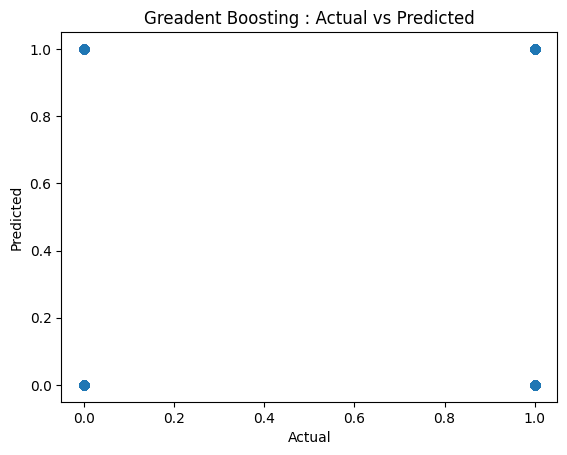

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Greadent Boosting : Actual vs Predicted')
plt.show()

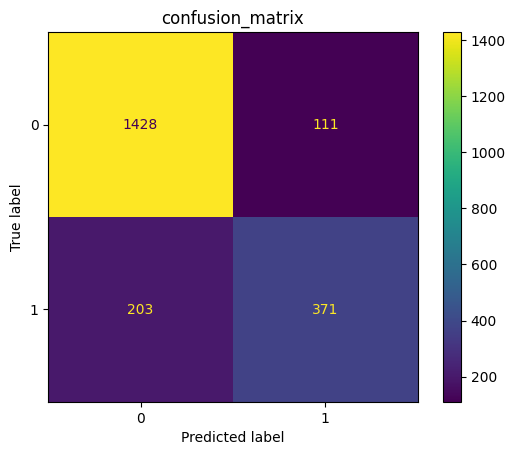

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd
cmd.from_estimator(model,X_test,y_test)
plt.title('confusion_matrix')
plt.show()

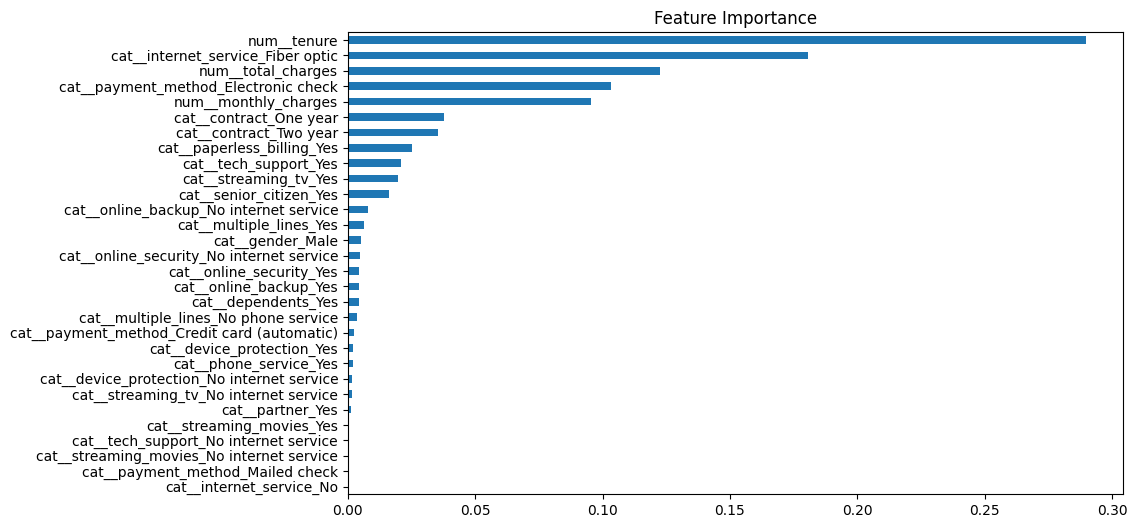

In [ ]:
# Extract model
gb_model = model.named_steps['classifier']

# Get importance
importances = gb_model.feature_importances_

# Get feature names
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

# Combine
import pandas as pd
feat_imp = pd.Series(importances, index=feature_names).sort_values()

# Plot
import matplotlib.pyplot as plt
feat_imp.plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

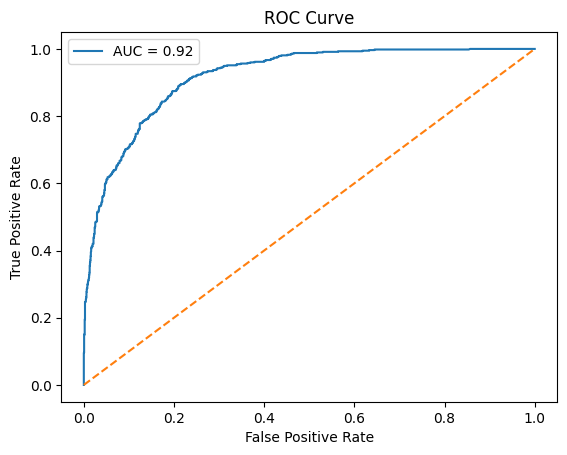

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Train Accuracy: 0.798580121703854
Test Accuracy: 0.8513961192617132


In [ ]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

4930 4930
2113 2113


##  GridSearchCV (Best but slow)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5],
    'classifier__subsample': [0.8, 1.0]
}

# GridSearch
grid = GridSearchCV(
    estimator=model,   # your pipeline
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best params
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

ValueError: Invalid parameter 'learning_rate' for estimator RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42). Valid parameters are: ['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'].

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

model = Pipeline(steps=[
    ('preprocessing', preprocesser),   # your ColumnTransformer
    ('scaling', StandardScaler()),     # important before PCA
    ('pca', PCA(n_components=0.95)),   # keep 95% variance
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

from sklearn.metrics import accuracy_score
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7920511000709723


Accuracy: 0.7920511000709723


## RandomizedSearchCV (FAST 🔥 Recommended)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'classifier__n_estimators': randint(100, 400),
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__max_depth': randint(3, 8),
    'classifier__subsample': uniform(0.7, 0.3)
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Best Params: {'classifier__learning_rate': np.float64(0.0430533878126005), 'classifier__max_depth': 3, 'classifier__n_estimators': 108, 'classifier__subsample': np.float64(0.9316734307889971)}


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [ ]:
cat = ['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']
num = [ 'monthly_charges', 'total_charges' , 'tenure']

In [ ]:
preprocesser = ColumnTransformer([
    ('num',StandardScaler(),num),
    ("cat",OneHotEncoder(drop='first'),cat)
])

In [ ]:
model = Pipeline(steps=[
    ('preprocessing' , preprocesser),
    ('classifier' , KNeighborsClassifier(n_neighbors=7))
])

In [ ]:
X = df.drop('churn',axis=1)
y = df['churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'tenure', 'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('classifier', KNeighborsClassifier(n_neighbors=7))])

In [ ]:
y_pred = model.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print(f'Classification Report : \n{classification_report(y_test,y_pred)}')

Accuracy : 0.7601135557132718
Classification Report : 
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1043
           1       0.54      0.50      0.52       366

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.76      1409



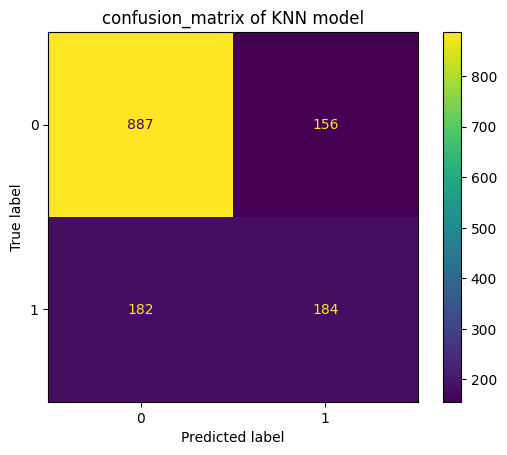

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd

cmd.from_estimator(model,X_test,y_test)
plt.title('confusion_matrix of KNN model')
plt.show()

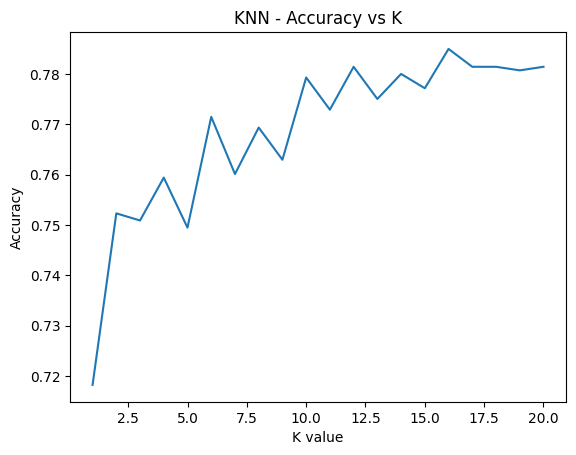

In [ ]:
from sklearn. neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

acc = []

for k in range(1, 21):
    knn_pipeline = Pipeline( [
       ("preprocess", preprocesser),
       ("model", KNeighborsClassifier(n_neighbors=k))

])

    knn_pipeline.fit(X_train, y_train)
    acc.append(knn_pipeline.score(X_test, y_test) )

plt.plot(range(1, 21), acc)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN - Accuracy vs K")
plt.show()

In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.8335108271210507
Test Accuracy: 0.7601135557132718


# **X_G_boost_classifier**

In [ ]:
from xgboost import XGBClassifier

In [ ]:
num = ['monthly_charges', 'total_charges','tenure']
cat = ['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']

In [ ]:
preprocesser = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num),
        ('cat',OneHotEncoder(drop='first'),cat)
])

In [ ]:
model = Pipeline(steps=[
    ('preprocessing',preprocesser),
    ('classifier',XGBClassifier())
])

In [ ]:
X = df.drop('churn',axis=1)
y = df['churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,)


In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streamin...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred = model.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print(f'Classification report: {classification_report(y_test,y_pred)}')

Accuracy : 0.794180269694819
Classification report:               precision    recall  f1-score   support

           0       0.85      0.88      0.86      1034
           1       0.63      0.56      0.59       375

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.9336173233936812
Test Accuracy: 0.794180269694819


# **SVM model**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.svm import SVC

In [ ]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [ ]:
num = ['monthly_charges', 'total_charges','tenure']
cat = ['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']

In [ ]:
preprocesser = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num),
        ('cat',OneHotEncoder(drop='first'),cat)
])

In [ ]:
model = Pipeline(
    steps=[
        ('preprocessing',preprocesser),
        ('classifier',SVC())
    ]
)

In [ ]:
X = df.drop('churn',axis=1)
y = df['churn']


X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['monthly_charges',
                                                   'total_charges', 'tenure']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('classifier', SVC())])

In [ ]:
y_pred = model.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print(f'Classification Report : \n{classification_report(y_test,y_pred)}')

Accuracy : 0.7977288857345636
Classification Report : 
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1012
           1       0.71      0.48      0.57       397

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.78      1409



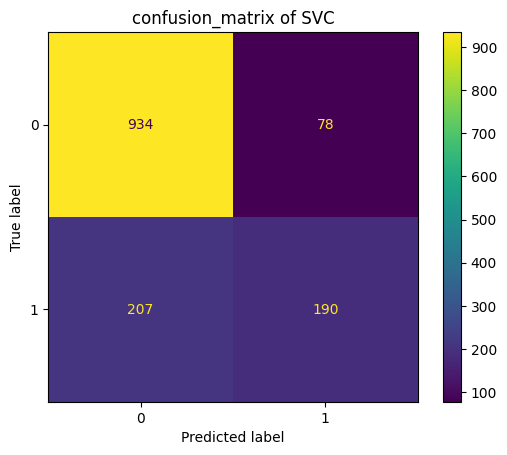

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd
cmd.from_estimator(model,X_test,y_test)
plt.title('confusion_matrix of SVC')
plt.show()

In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred)*100)
print("Test Accuracy:", accuracy_score(y_test, y_pred)*100)

Train Accuracy: 81.70039048633298
Test Accuracy: 79.77288857345636


# XG boost

In [ ]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report



# 4. Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 5. Define features and target
X = df.drop('churn', axis=1)
y = df['churn']

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train XGBoost model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)

# 9. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8041163946061036

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [ ]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.8470003549875754
Test Accuracy: 0.8041163946061036
